In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Understand the structure

In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


Check Data Quality

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["TotalCharges"].dtype

dtype('O')

Fix TotalCharges

Convert the column to numbers, and turn anything that can't convert into NaN:

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

In [10]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [11]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["TotalCharges"].isnull().sum()
df["TotalCharges"].dtype

dtype('float64')

Drop the ID column- customerID is unique to each row, so it carries no predictive signal:

In [12]:
df = df.drop("customerID", axis=1)
df.shape

(7043, 20)

In [13]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


What is EDA?

EDA (Exploratory Data Analysis) means looking at the data through charts and summaries before building any model. Day 1 was about cleaning the data. Day 2 is about learning what the data is telling us. The model comes later, and EDA helps us understand why it behaves the way it does.

Step 1: Set up

In [14]:
import os
os.makedirs("images", exist_ok=True)
sns.set_style("whitegrid")

Step 2: Chart 1, how many customers churn?

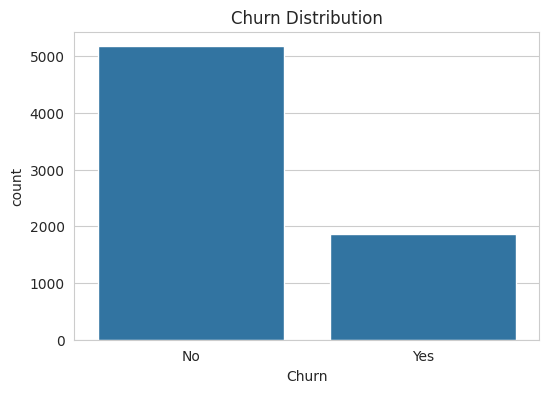

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.savefig("images/churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Step 3: Chart 2, which contract type churns most?

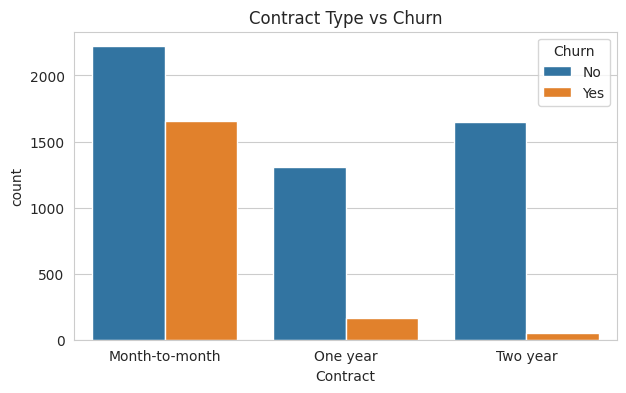

In [16]:
plt.figure(figsize=(7, 4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.savefig("images/contract_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

Step 4: Check the churn rate per contract

In [17]:
df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)

,Churn
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


Step 5: Chart 3, does the monthly bill affect churn?

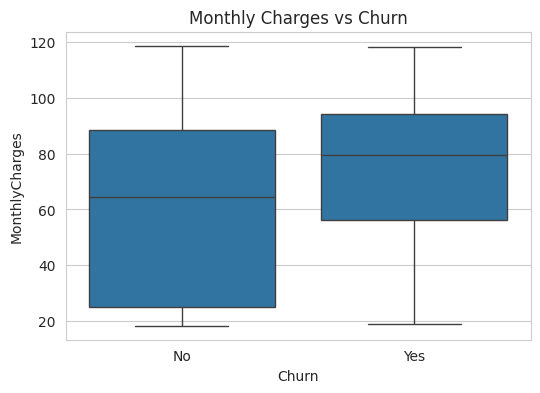

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.savefig("images/monthly_charges_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

Step 6: Chart 4, does tenure matter?

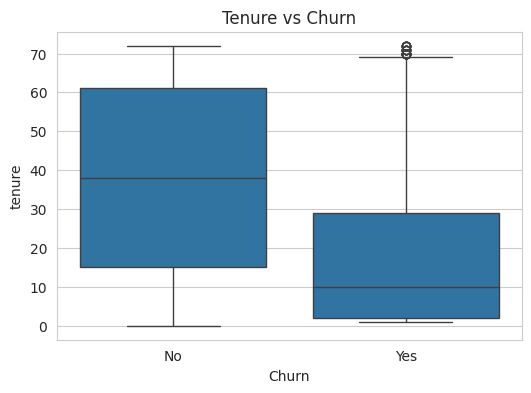

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.savefig("images/tenure_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

Step 7: Chart 5, the correlation heatmap

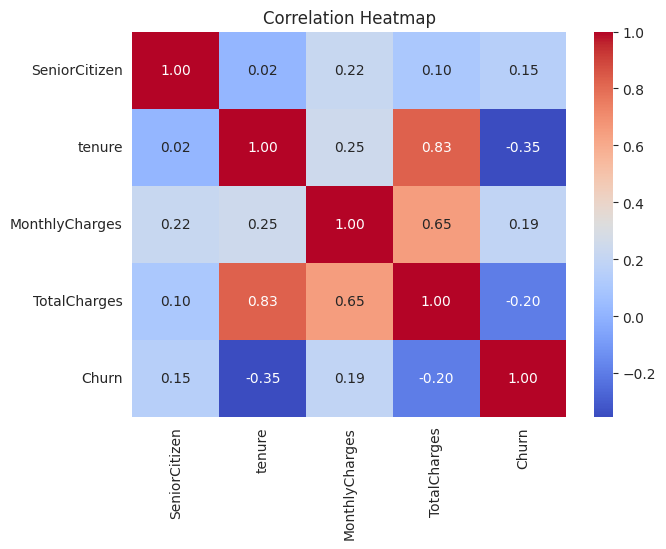

In [20]:
temp = df.copy()
temp["Churn"] = temp["Churn"].map({"Yes": 1, "No": 0})

plt.figure(figsize=(7, 5))
sns.heatmap(temp.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("images/heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
!zip -r images.zip images

  adding: images/ (stored 0%)
  adding: images/heatmap.png (deflated 10%)
  adding: images/tenure_vs_churn.png (deflated 21%)
  adding: images/churn_distribution.png (deflated 26%)
  adding: images/contract_vs_churn.png (deflated 21%)
  adding: images/monthly_charges_vs_churn.png (deflated 20%)


## Key Insights from EDA

1. **Class imbalance:** About 26.5% of customers churn and 73.5% stay. Accuracy alone is misleading, so models will be evaluated with precision, recall, and F1.

2. **Contract type:** Month-to-month customers churn at 42.7%, compared to 11.3% for one-year and 2.8% for two-year contracts. This is the strongest pattern found.

3. **Tenure:** Churners have a median tenure of about 10 months versus about 38 months for stayers. The first year is the highest-risk period.

4. **Monthly charges:** Churners pay more per month (median about 80 versus about 64), so higher bills are linked to higher churn.

5. **Correlations:** Tenure has the strongest correlation with churn (-0.35). Tenure and TotalCharges are highly correlated with each other (0.83).

6. **At-risk customer profile:** New customers on a month-to-month contract with a higher monthly bill are the most likely to leave.

Preprocessing

Models only understand numbers, so we convert everything into numeric form and prepare the data for training. Each step below has a plain-words reason.

Step 1: Make a working copy

Step 1: Make a working copy

In [22]:
df_model = df.copy()

Step 2: Convert the target to 1/0

In [23]:
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})
df_model["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


The model predicts numbers, so Yes becomes 1 and No becomes 0.

Step 3: Look at the text columns

In [24]:
for col in df_model.select_dtypes(include="object").columns:
    print(col, df_model[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


Step 4: Label-encode the two-value columns

In [25]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

Step 5: One-hot encode the rest

In [26]:
df_model = pd.get_dummies(df_model, drop_first=True, dtype=int)
df_model.shape

(7043, 31)

Step 6: Split into X and y, then train/test

In [27]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 30) (1409, 30)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


We train on 80% of customers and test on the other 20%, which the model has never seen, like an exam with new questions. Two settings are worth knowing:

random_state=42 makes the split repeatable.
stratify=y keeps the 73/27 churn ratio the same in both sets. Without it, the test set could end up with too few churners by chance, which matters a lot for our imbalanced data.

Step 7: Scale the numeric columns

In [28]:
from sklearn.preprocessing import StandardScaler

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


We turned Yes/No into 1/0 for the target and the two-value columns.
We turned multi-category columns (Contract, InternetService, PaymentMethod) into separate 0/1 columns, so the model doesn't think "Two year" is bigger than "Month-to-month".
We split the customers into a study group (80%) and an exam group (20%), keeping the churn ratio the same in both.
We put the numeric columns on a common scale, learning the scale from the study group only, so nothing from the exam leaks in.

Building out training, evaluation, and coefficient analysis steps.
What is Logistic Regression? (easy words)
Imagine the model as a scoring system. For each customer, it looks at every feature and adds up points:

Month-to-month contract: adds risk points.
Long tenure: removes risk points.
Higher monthly bill: adds a few risk points.
It then converts the total score into a probability between 0 and 1, like "this customer has a 0.72 chance of leaving". If the probability is above 0.5, it predicts Churn. Otherwise it predicts Stay.

Why "regression" if it classifies? Inside, it uses the same weighted-sum idea as linear regression. The final step squeezes that score into a probability, and we turn the probability into a label.

Why we start with it: it's simple, fast, and explainable. We can see exactly which features push churn up or down, which is what a business wants to know.

Step 1: Train the model

In [29]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Step 2: Predict on the test set

In [30]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print(y_pred_log[:10])
print(y_prob_log[:10].round(2))

[0 1 0 0 0 1 0 0 0 0]
[0.05 0.68 0.06 0.4  0.02 0.6  0.45 0.13 0.   0.4 ]


Step 3: Evaluate

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8062455642299503
[[927 108]
 [165 209]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Step 4: Save a confusion matrix image

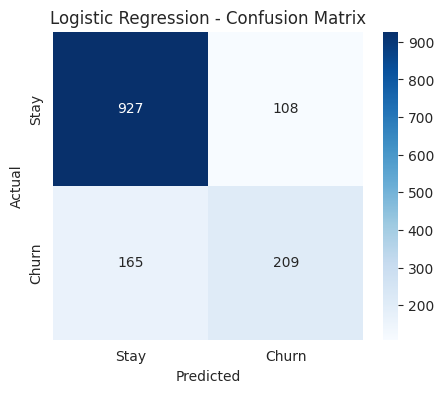

In [32]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.savefig("images/confusion_matrix_logistic.png", dpi=150, bbox_inches="tight")
plt.show()

Step 5: Which features matter?

In [33]:
coef = pd.Series(log_model.coef_[0], index=X_train.columns)
coef_sorted = coef.reindex(coef.abs().sort_values(ascending=False).index)
print(coef_sorted.head(10))

Contract_Two year                -1.313803
tenure                           -1.257131
InternetService_Fiber optic       1.180666
Contract_One year                -0.683857
TotalCharges                      0.527772
PhoneService                     -0.520750
MonthlyCharges                   -0.466504
PaymentMethod_Electronic check    0.392775
StreamingTV_Yes                   0.374831
PaperlessBilling                  0.374218
dtype: float64


## Logistic Regression Results

- **Accuracy:** 80.6% (baseline of always predicting "Stay" is 73.5%)
- **Churn class:** Precision 0.66, Recall 0.56, F1 0.60
- The model misses 165 of 374 actual churners (recall 56%), so many at-risk customers go undetected.
- **Strongest churn reducers:** two-year contract, one-year contract, longer tenure.
- **Strongest churn drivers:** fiber optic internet, electronic check payment, streaming TV, paperless billing.
- Tenure, MonthlyCharges and TotalCharges are correlated, so their individual coefficients should be interpreted with caution.

Step 1: Train an unrestricted tree

In [34]:
from sklearn.tree import DecisionTreeClassifier

tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

print("Train accuracy:", tree_full.score(X_train, y_train))
print("Test accuracy:", tree_full.score(X_test, y_test))

Train accuracy: 0.9980475683351083
Test accuracy: 0.7310149041873669


Step 2: Evaluate the unrestricted tree

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_full = tree_full.predict(X_test)
print(confusion_matrix(y_test, y_pred_full))
print(classification_report(y_test, y_pred_full))

[[853 182]
 [197 177]]
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1035
           1       0.49      0.47      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



Step 3: Train a limited tree

We stop the tree from growing too deep by setting max_depth=5, so it can ask at most 5 questions in a row:

In [36]:
tree_small = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_small.fit(X_train, y_train)

print("Train accuracy:", tree_small.score(X_train, y_train))
print("Test accuracy:", tree_small.score(X_test, y_test))

Train accuracy: 0.8022719204827831
Test accuracy: 0.794180269694819


Step 4: Evaluate the limited tree

[[917 118]
 [172 202]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



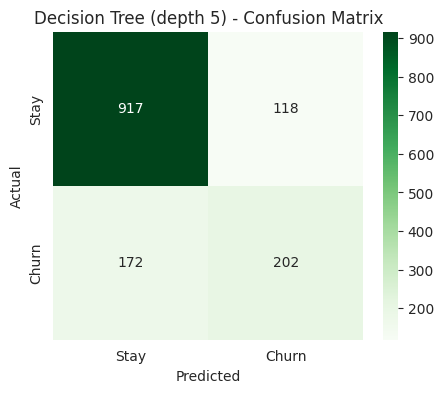

In [37]:
y_pred_small = tree_small.predict(X_test)
print(confusion_matrix(y_test, y_pred_small))
print(classification_report(y_test, y_pred_small))

cm = confusion_matrix(y_test, y_pred_small)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree (depth 5) - Confusion Matrix")
plt.savefig("images/confusion_matrix_tree.png", dpi=150, bbox_inches="tight")
plt.show()

Step 5: Draw the tree

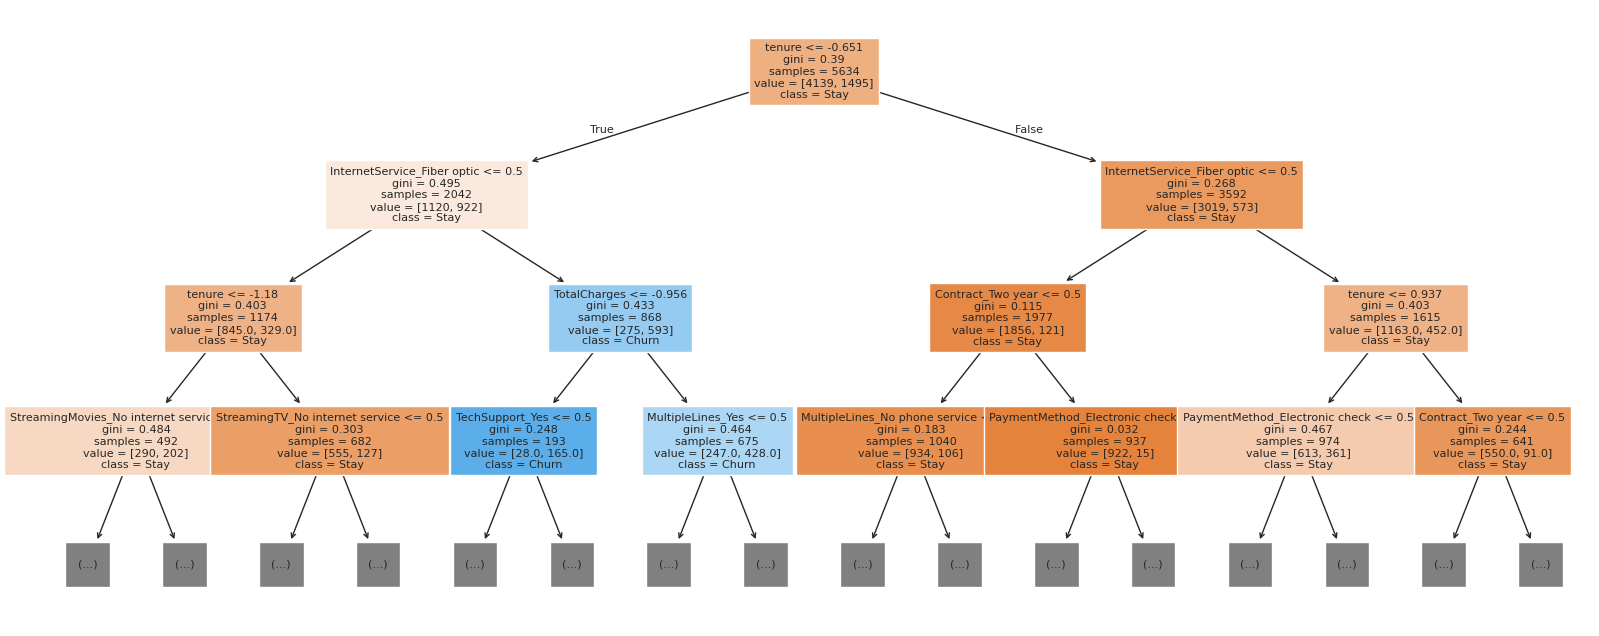

In [38]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(tree_small, feature_names=X_train.columns, class_names=["Stay", "Churn"],
          filled=True, max_depth=3, fontsize=8)
plt.savefig("images/decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

Step 6: Which features does the tree use most?

In [39]:
imp = pd.Series(tree_small.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(10).round(3))

tenure                                 0.422
InternetService_Fiber optic            0.358
TotalCharges                           0.037
PaymentMethod_Electronic check         0.037
MonthlyCharges                         0.025
MultipleLines_Yes                      0.024
StreamingMovies_No internet service    0.021
Contract_Two year                      0.020
StreamingTV_No internet service        0.017
TechSupport_Yes                        0.013
dtype: float64


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree (unrestricted)": y_pred_full,
    "Decision Tree (max_depth=5)": y_pred_small,
}

rows = []
for name, pred in models.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })

results = pd.DataFrame(rows).round(3)
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.806,0.659,0.559,0.605
1,Decision Tree (unrestricted),0.731,0.493,0.473,0.483
2,Decision Tree (max_depth=5),0.794,0.631,0.540,0.582


## Conclusion

Logistic Regression performed best across all metrics (Accuracy 0.806, Precision 0.659,
Recall 0.559, F1 0.605) and is also the most interpretable model through its coefficients.

The unrestricted Decision Tree overfit the training data (99.8% train accuracy vs 73.1%
test accuracy). Limiting its depth to 5 closed most of that gap (80.2% train vs 79.4% test)
and brought its performance close to Logistic Regression.

**Business drivers of churn (consistent across EDA, coefficients, and the tree splits):**
- Increases churn: month-to-month contract, short tenure, fiber optic internet,
  electronic check payment
- Reduces churn: longer tenure, one/two-year contracts

**Main limitation:** recall is 56%, meaning the model misses about 44% of customers
who actually churn. Lowering the classification threshold below 0.5 would catch more
churners at the cost of more false alarms.

**Recommendation:** target retention offers at month-to-month, low-tenure, fiber optic
customers, and consider incentivizing longer contract commitments.